In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
def load_tracts(state_fips):
    print(f"\nLoading tracts for state {state_fips}...")

    url = f"https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_{state_fips}_tract.zip"
    gdf = gpd.read_file(url)

    print("Total tracts loaded:", len(gdf))
    return gdf

def filter_counties(gdf, county_list, city_name="city"):
    print(f"\nFiltering tracts for {city_name}...")

    out = gdf[gdf["COUNTYFP"].isin(county_list)].copy()

    print(f"{city_name} tracts:", len(out))
    print(out[["GEOID", "COUNTYFP"]].head())

    return out

In [3]:
NYC_STATE = "36" # New York State

NYC_COUNTIES = [
    "005",  # Bronx
    "047",  # Brooklyn
    "061",  # Manhattan
    "081",  # Queens
    "085"   # Staten Island
]


Loading tracts for state 36...
Total tracts loaded: 5411

Filtering tracts for NYC...
NYC tracts: 2327
          GEOID COUNTYFP
3   36081003400      081
4   36081003900      081
8   36081003600      081
9   36081003700      081
10  36081003800      081

Plotting NYC...


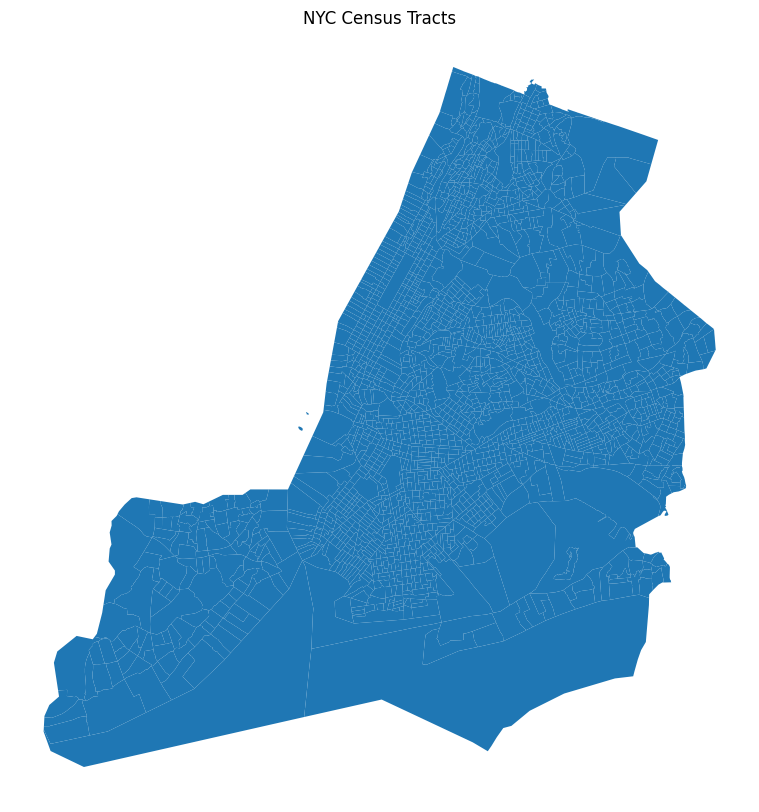

In [4]:
nyc_tracts = load_tracts(NYC_STATE)
nyc_tracts = filter_counties(nyc_tracts, NYC_COUNTIES, "NYC")

print("\nPlotting NYC...")
nyc_tracts.plot(figsize=(10, 10), linewidth=0.2)
plt.title("NYC Census Tracts")
plt.axis("off")
plt.show()

In [5]:
LA_STATE = "06"  # California

LA_COUNTIES = [
    "037",  # Los Angeles County
    "059",  # Orange County
    "111"   # Ventura County
]


Loading tracts for state 06...
Total tracts loaded: 9129

Filtering tracts for Los Angeles...
Los Angeles tracts: 3302
         GEOID COUNTYFP
2  06037204920      037
3  06037205110      037
4  06037320101      037
5  06037205120      037
6  06037206010      037

Plotting Los Angeles...


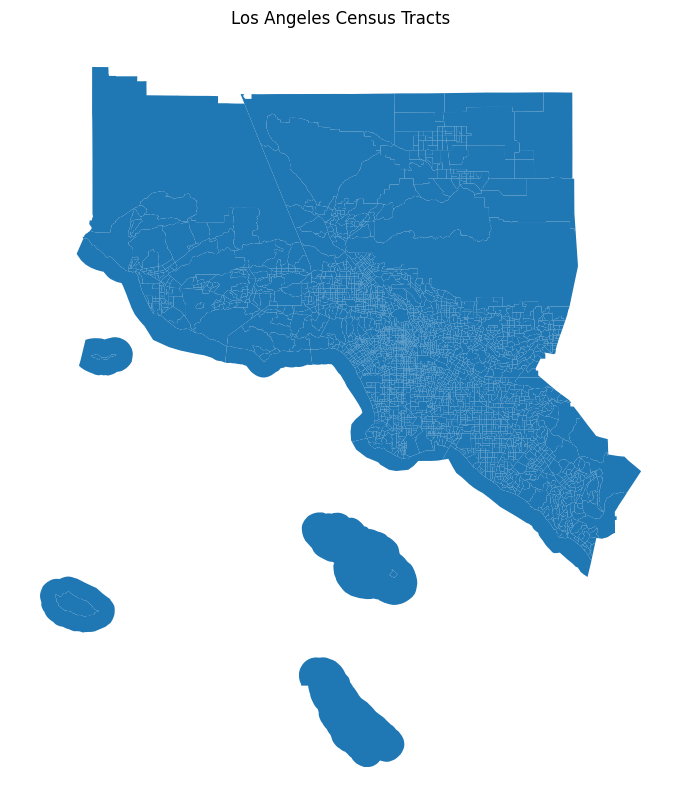

In [6]:
la_tracts = load_tracts(LA_STATE)
la_tracts = filter_counties(la_tracts, LA_COUNTIES, "Los Angeles")

print("\nPlotting Los Angeles...")
la_tracts.plot(figsize=(10, 10), linewidth=0.2)
plt.title("Los Angeles Census Tracts")
plt.axis("off")
plt.show()

In [7]:
# %%
import censusdata
import pandas as pd

In [8]:
# %%
ACS_VARIABLES = {

    # Total population
    "total_population": "B01003_001E",

    # Median income
    "median_income": "B19013_001E",

    # AGE — B01001
    # Male under 18
    "m_under_5": "B01001_003E",
    "m_5_9": "B01001_004E",
    "m_10_14": "B01001_005E",
    "m_15_17": "B01001_006E",

    # Female under 18
    "f_under_5": "B01001_027E",
    "f_5_9": "B01001_028E",
    "f_10_14": "B01001_029E",
    "f_15_17": "B01001_030E",

    # Male 65+
    "m_65_66": "B01001_020E",
    "m_67_69": "B01001_021E",
    "m_70_74": "B01001_022E",
    "m_75_79": "B01001_023E",
    "m_80_84": "B01001_024E",
    "m_85_plus": "B01001_025E",

    # Female 65+
    "f_65_66": "B01001_044E",
    "f_67_69": "B01001_045E",
    "f_70_74": "B01001_046E",
    "f_75_79": "B01001_047E",
    "f_80_84": "B01001_048E",
    "f_85_plus": "B01001_049E",

    # EDUCATION — B15003
    "bachelors": "B15003_022E",
    "masters": "B15003_023E",
    "professional": "B15003_024E",
    "doctorate": "B15003_025E",
    "pop_25_plus": "B15003_001E",

    # EMPLOYMENT — B23025
    "labor_force": "B23025_003E",
    "employed": "B23025_004E",

    # POVERTY — B17001
    "poverty_total": "B17001_001E",
    "below_poverty": "B17001_002E"
}

In [9]:
def load_acs_features(state_fips, county_list, year=2022):

    print(f"\nLoading ACS features for state {state_fips}...")

    all_data = []

    vars_to_pull = list(ACS_VARIABLES.values())

    for county in county_list:

        print(f"\nProcessing county {county}...")

        geo = censusdata.censusgeo([
            ("state", state_fips),
            ("county", county),
            ("tract", "*")
        ])

        df = censusdata.download(
            src="acs5",
            year=year,
            geo=geo,
            var=vars_to_pull
        )

        df = df.reset_index()

        # Rename ACS columns
        rename_dict = {
            v: k for k, v in ACS_VARIABLES.items()
        }

        df = df.rename(columns=rename_dict)

        # CORRECT GEOID EXTRACTION
        df["tract_id"] = df["index"].apply(
            lambda x: "".join([v for k, v in x.geo])
        )

        print("Rows loaded:", len(df))
        print(df[["tract_id", "total_population", "median_income"]].head())

        all_data.append(df)

    acs = pd.concat(all_data, ignore_index=True)

    print("\nFinal ACS shape:", acs.shape)

    return acs

In [10]:
# %%
def compute_acs_features(df):

    print("\nComputing derived ACS features...")

    # Replace ACS missing-value codes with NaN
    missing_codes = [-666666666, -333333333, -222222222]

    numeric_cols = df.select_dtypes(include="number").columns

    for col in numeric_cols:
        df[col] = df[col].mask(df[col].isin(missing_codes))

    # UNDER 18
    under_18_cols = [
        "m_under_5", "m_5_9", "m_10_14", "m_15_17",
        "f_under_5", "f_5_9", "f_10_14", "f_15_17"
    ]

    df["population_under_18"] = df[under_18_cols].sum(axis=1)

    # OVER 65
    over_65_cols = [
        "m_65_66", "m_67_69", "m_70_74",
        "m_75_79", "m_80_84", "m_85_plus",
        "f_65_66", "f_67_69", "f_70_74",
        "f_75_79", "f_80_84", "f_85_plus"
    ]

    df["population_over_65"] = df[over_65_cols].sum(axis=1)

    # Bachelor's+
    bachelors_cols = [
        "bachelors",
        "masters",
        "professional",
        "doctorate"
    ]

    df["bachelors_or_higher"] = df[bachelors_cols].sum(axis=1)

    # FINAL FEATURES
    df["pct_under_18"] = (
        df["population_under_18"] / df["total_population"]
    )

    df["pct_over_65"] = (
        df["population_over_65"] / df["total_population"]
    )

    df["pct_bachelors_degree"] = (
        df["bachelors_or_higher"] / df["pop_25_plus"]
    )

    df["employment_rate"] = (
        df["employed"] / df["labor_force"]
    )

    df["poverty_rate"] = (
        df["below_poverty"] / df["poverty_total"]
    )

    print("\nDerived features created:")
    print([
        "pct_under_18",
        "pct_over_65",
        "pct_bachelors_degree",
        "employment_rate",
        "poverty_rate"
    ])

    return df

In [11]:
# %%
def merge_acs_features(tracts_gdf, acs_df):

    print("\nMerging ACS features with tract geometries...")

    tracts_gdf["tract_id"] = tracts_gdf["GEOID"]

    merged = tracts_gdf.merge(
        acs_df,
        on="tract_id",
        how="left"
    )

    print("Merged shape:", merged.shape)

    cols_to_check = [
        "tract_id",
        "total_population",
        "median_income",
        "pct_under_18",
        "pct_over_65",
        "pct_bachelors_degree",
        "employment_rate",
        "poverty_rate"
    ]

    print("\nSample merged rows:")
    print(merged[cols_to_check].head())

    return merged

In [12]:
# %%
nyc_acs = load_acs_features(
    NYC_STATE,
    NYC_COUNTIES
)

nyc_acs = compute_acs_features(nyc_acs)

nyc_tracts = merge_acs_features(
    nyc_tracts,
    nyc_acs
)


Loading ACS features for state 36...

Processing county 005...
Rows loaded: 361
      tract_id  total_population  median_income
0  36005000100              4446     -666666666
1  36005000200              4870         115064
2  36005000400              6257         100553
3  36005001600              6177          41362
4  36005001901              2181          49500

Processing county 047...
Rows loaded: 805
      tract_id  total_population  median_income
0  36047000100              4974         165188
1  36047000200              1170          78942
2  36047000301              4057         193158
3  36047000501              4432         140795
4  36047000502              2774         169313

Processing county 061...
Rows loaded: 310
      tract_id  total_population  median_income
0  36061000100                 0     -666666666
1  36061000201              2666          45582
2  36061000202              7001          34710
3  36061000500                 0     -666666666
4  36061000600   

In [13]:
cols = [
    "total_population",
    "median_income",
    "pct_under_18",
    "pct_over_65",
    "pct_bachelors_degree",
    "employment_rate",
    "poverty_rate"
]

print(nyc_tracts[cols].describe())

       total_population  median_income  pct_under_18  pct_over_65  \
count       2327.000000    2201.000000   2242.000000  2242.000000   
mean        3705.400516   85195.831895      0.202730     0.157446   
std         2061.952453   41342.317713      0.079435     0.078108   
min            0.000000   11406.000000      0.000000     0.000000   
25%         2293.000000   57340.000000      0.153358     0.108457   
50%         3445.000000   78750.000000      0.199191     0.145781   
75%         4873.000000  103673.000000      0.246337     0.197399   
max        15945.000000  250001.000000      0.676439     0.910345   

       pct_bachelors_degree  employment_rate  poverty_rate  
count           2242.000000      2237.000000   2237.000000  
mean               0.381071         0.922929      0.165785  
std                0.215217         0.055938      0.124528  
min                0.000000         0.117647      0.000000  
25%                0.219513         0.899316      0.075569  
50%         

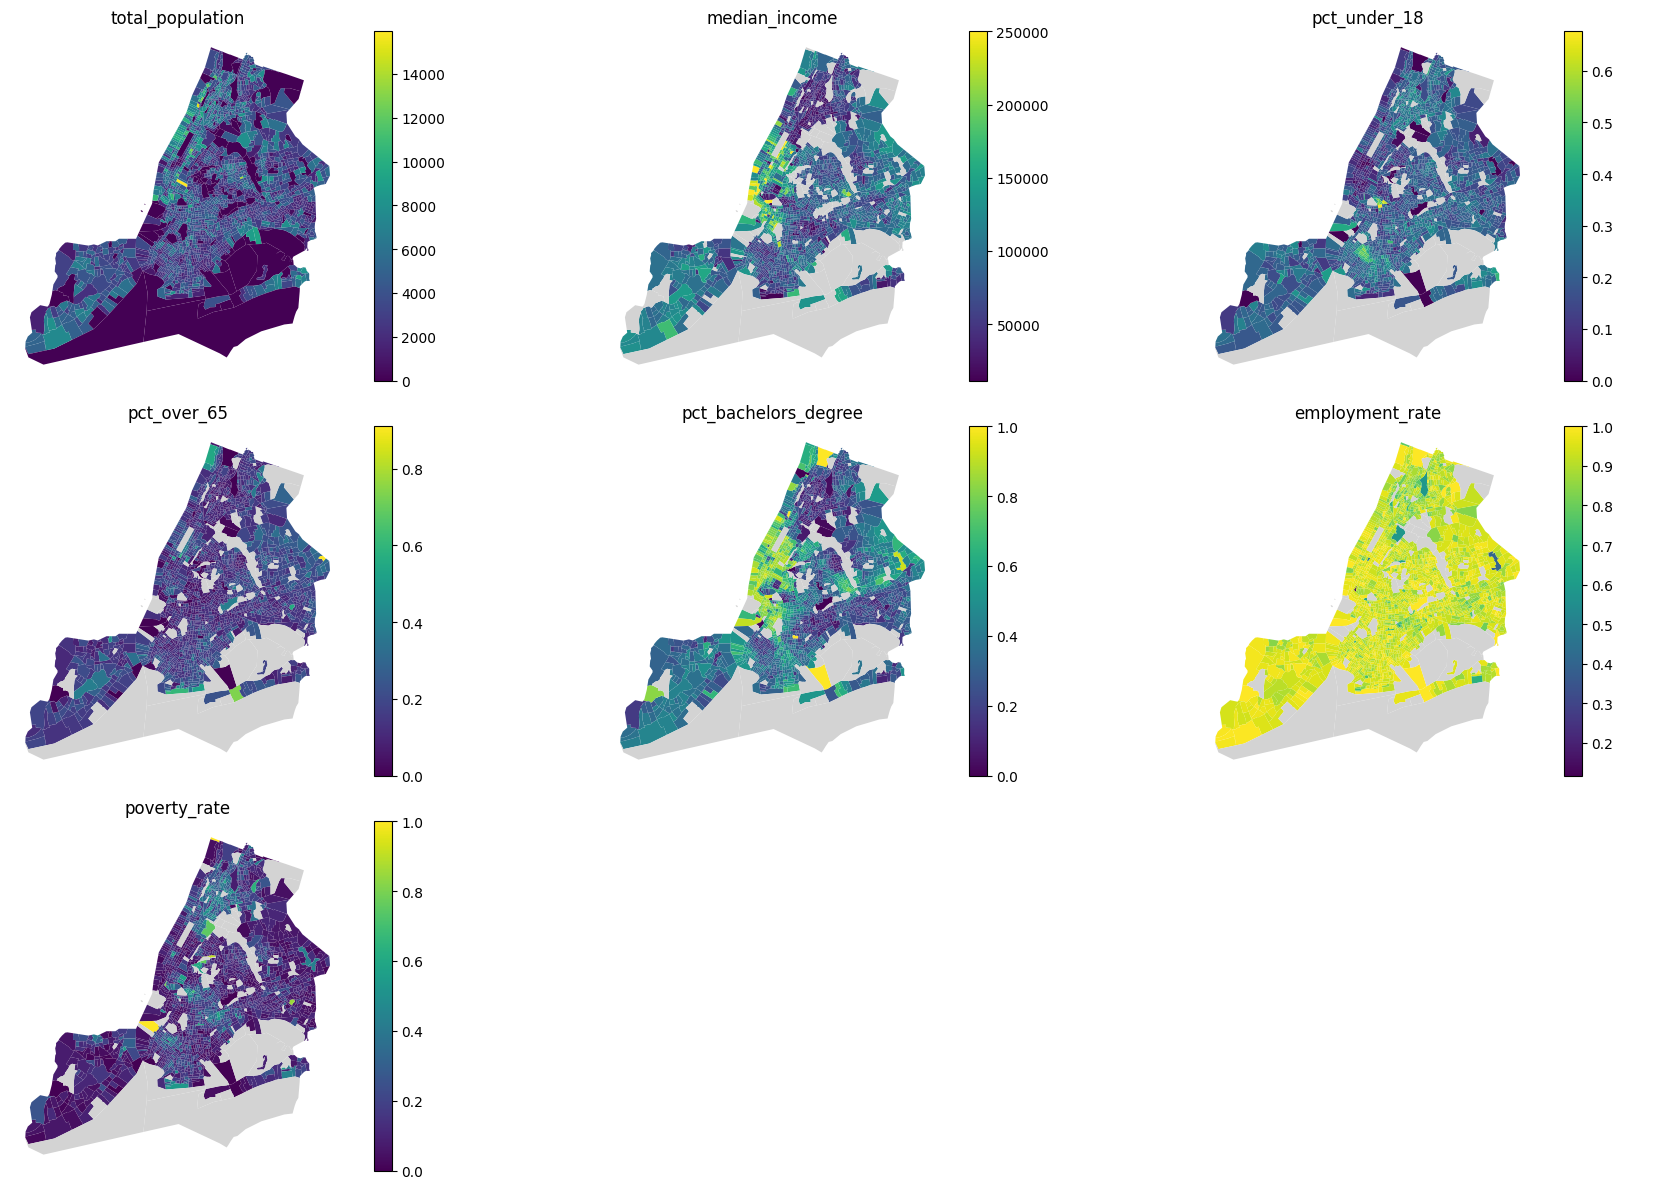

In [14]:
import matplotlib.pyplot as plt

features = [
    "total_population",
    "median_income",
    "pct_under_18",
    "pct_over_65",
    "pct_bachelors_degree",
    "employment_rate",
    "poverty_rate"
]

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))

axes = axes.flatten()

for i, var in enumerate(features):

    nyc_tracts.plot(
        column=var,
        cmap="viridis",
        legend=True,
        ax=axes[i],
        missing_kwds={"color": "lightgrey"}
    )

    axes[i].set_title(var)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [15]:
# %%
la_acs = load_acs_features(
    LA_STATE,
    LA_COUNTIES
)

la_acs = compute_acs_features(la_acs)

la_tracts = merge_acs_features(
    la_tracts,
    la_acs
)


Loading ACS features for state 06...

Processing county 037...
Rows loaded: 2498
      tract_id  total_population  median_income
0  06037101110              4014          68972
1  06037101122              4164         118859
2  06037101220              3481          65139
3  06037101221              3756          53348
4  06037101222              2808          36779

Processing county 059...
Rows loaded: 614
      tract_id  total_population  median_income
0  06059001101              4896         114898
1  06059001102              3404         124150
2  06059001103              5074          88611
3  06059001201              5409          82611
4  06059001202              3734          82000

Processing county 111...
Rows loaded: 190
      tract_id  total_population  median_income
0  06111000302              8454          76442
1  06111000303              5280          95132
2  06111000304              4487          83000
3  06111000400              6880          70242
4  06111000500  

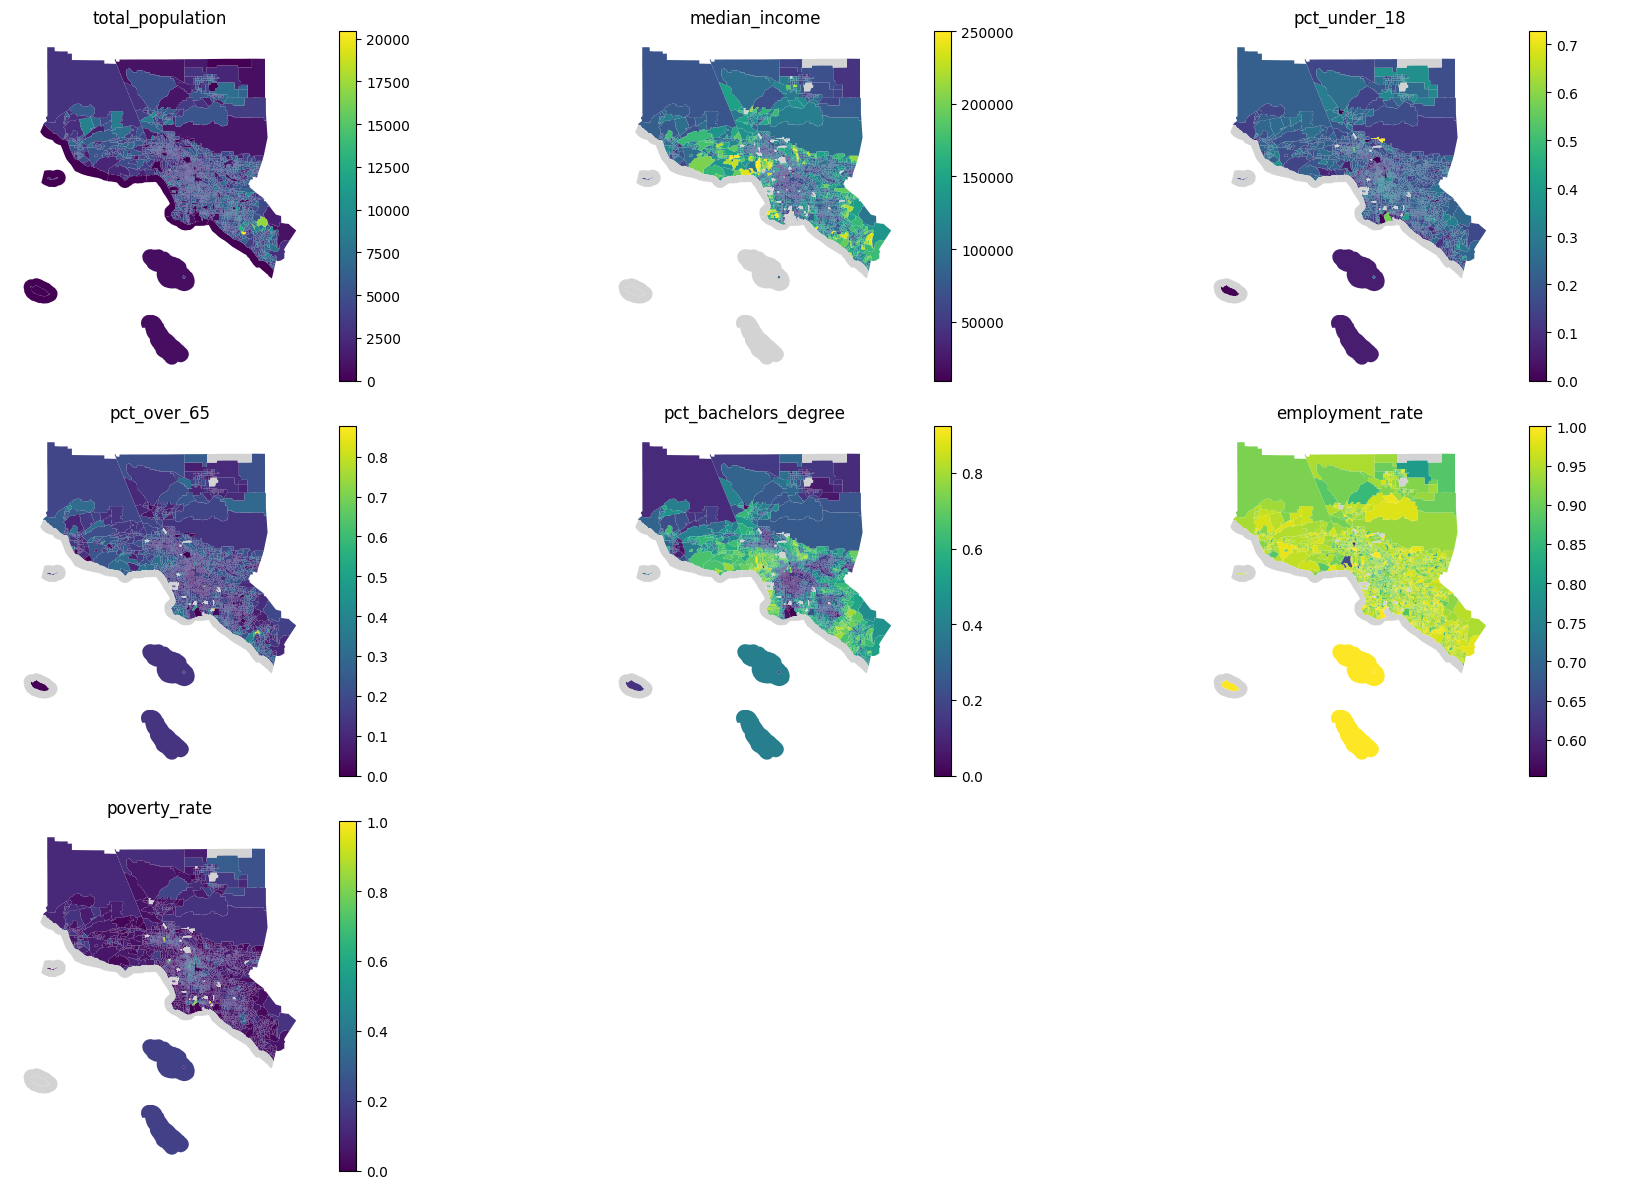

In [16]:
import matplotlib.pyplot as plt

features = [
    "total_population",
    "median_income",
    "pct_under_18",
    "pct_over_65",
    "pct_bachelors_degree",
    "employment_rate",
    "poverty_rate"
]

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))

axes = axes.flatten()

for i, var in enumerate(features):

    la_tracts.plot(
        column=var,
        cmap="viridis",
        legend=True,
        ax=axes[i],
        missing_kwds={"color": "lightgrey"}
    )

    axes[i].set_title(var)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()